In [1]:
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from nltk.corpus import stopwords
from transformers import AutoTokenizer
from wordcloud import WordCloud

load_dotenv()

True

In [2]:
df = pd.read_csv("data/dontpatronizeme_pcl.tsv", sep="\t")
df.head()

,par_id,art_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


# Technique 1
## Basic Statistical Profiling: Class Distribution

In [3]:
df["label_pcl"] = (df["label"] >= 2).astype(int)
df.head()

,par_id,art_id,keyword,country_code,text,label,label_pcl
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0,0


In [4]:
df.tail()

,par_id,art_id,keyword,country_code,text,label,label_pcl
10464,10465,@@14297363,women,lk,Sri Lankan norms and culture inhibit women fro...,1,0
10465,10466,@@70091353,vulnerable,ph,He added that the AFP will continue to bank on...,0,0
10466,10467,@@20282330,in-need,ng,""" She has one huge platform , and information ...",3,1
10467,10468,@@16753236,hopeless,in,""" Anja Ringgren Loven I ca n't find a word to ...",4,1
10468,10469,@@16779383,homeless,ie,""" Guinness World Record of 540lbs of 7-layer m...",3,1


In [5]:
df["label_pcl"].value_counts(normalize=False)

label_pcl
0    9476
1     993
Name: count, dtype: int64

In [6]:
df["label_pcl"].value_counts(normalize=True)

label_pcl
0    0.905149
1    0.094851
Name: proportion, dtype: float64

# Technique 2
## Lexical Analysis: Stop Word Density

In [7]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))


def stopword_density(text):
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    stop_count = sum(1 for w in words if w in stop_words)
    return stop_count / len(words)


df['stopword_density'] = df['text'].apply(stopword_density)

df['stopword_density'].describe()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/henrytsyu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


count    10469.000000
mean         0.370578
std          0.081700
min          0.000000
25%          0.320000
50%          0.373333
75%          0.424242
max          0.645161
Name: stopword_density, dtype: float64

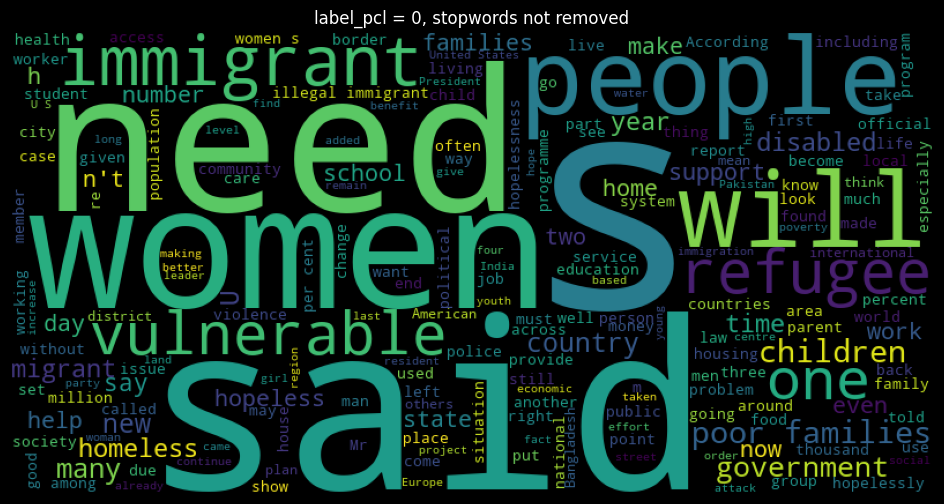

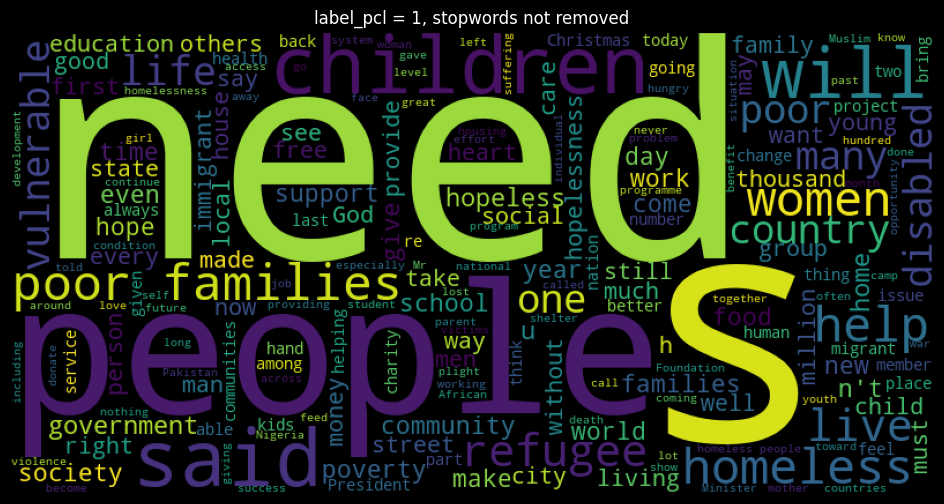

In [8]:
for label in [0, 1]:
    text = ' '.join(df[df['label_pcl'] == label]['text'].dropna().astype(str))
    wc = WordCloud(width=800, height=400).generate(text)
    plt.figure(figsize=(12, 6))
    plt.title(f'label_pcl = {label}, stopwords not removed')
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

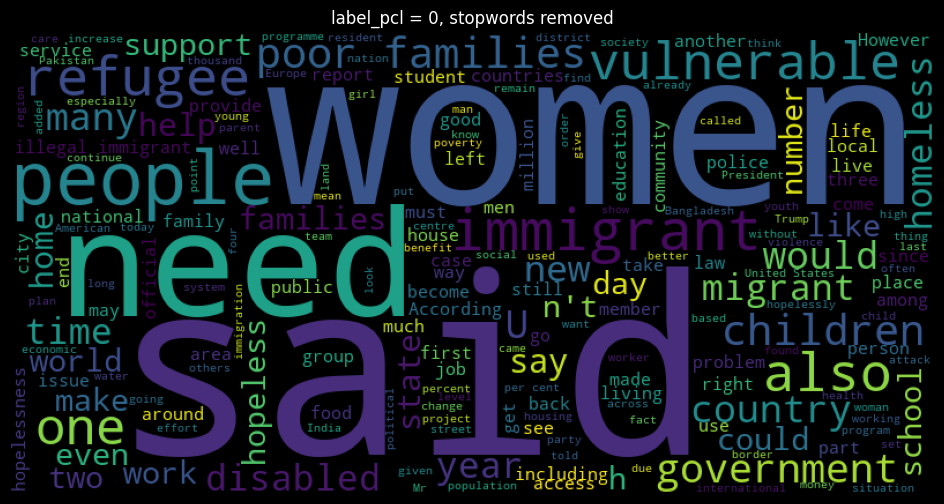

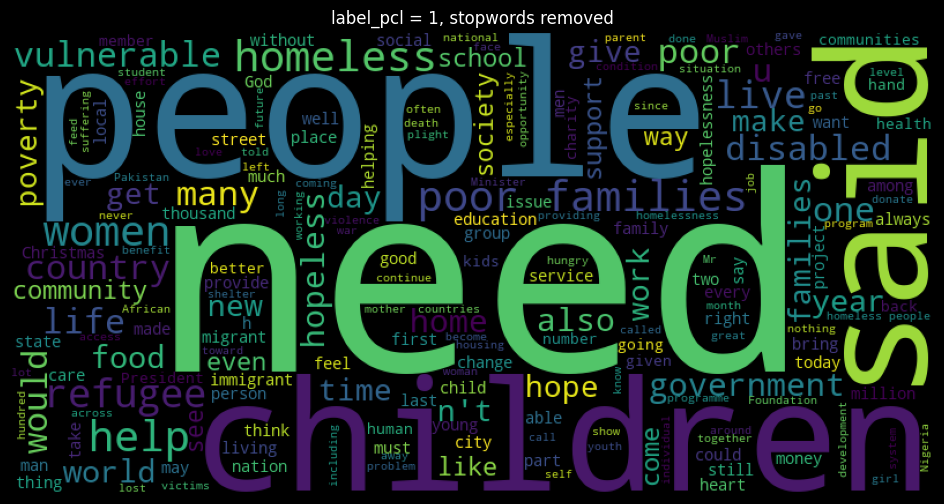

In [9]:
for label in [0, 1]:
    text = ' '.join(df[df['label_pcl'] == label]['text'].dropna().astype(str))
    wc = WordCloud(width=800, height=400, stopwords=stop_words).generate(text)
    plt.figure(figsize=(12, 6))
    plt.title(f'label_pcl = {label}, stopwords removed')
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [10]:
len(stop_words)

198

In [11]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [13]:
# Custom stop words based on EDA
custom_stopwords = {'said', 'the', 'is', 'and'}


def clean_and_prepend(row):
    # Filter stop words from the text
    words = str(row['text']).lower().split()
    cleaned_words = [word for word in words if word not in custom_stopwords]
    cleaned_text = " ".join(cleaned_words)

    # Glue the keyword and country to the front
    return f"Keyword: {row['keyword']}. Country: {row['country_code']}. Text: {cleaned_text}"


# Apply the function across the rows (axis=1)
df["cleaned_text"] = df.apply(clean_and_prepend, axis=1)

# Additional (not included in report)
## Token Length Analysis

In [14]:
# 1. Load the RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# 2. Find the token length for every row in your dataset
# (encode() turns the text into numbers to count the exact length)
token_lengths = df["cleaned_text"].apply(lambda x: len(tokenizer.encode(str(x))))

# 3. Print the statistics to help you decide
print("Average length:", np.mean(token_lengths))
print("95th percentile:", np.percentile(token_lengths, 95))
print("Max length:", np.max(token_lengths))

Token indices sequence length is longer than the specified maximum sequence length for this model (533 > 512). Running this sequence through the model will result in indexing errors


Average length: 64.75527748591078
95th percentile: 120.0
Max length: 960
